<a href="https://colab.research.google.com/github/vartiens/DeepLearningTrials/blob/main/aice2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 탐색적 데이터 분석 (EDA)

데이터를 어떻게 분석할 것인지, 어떻게 가공할 것인지 결정

## 일변량 분석

.describe() -> 수치 데이터의 통계 값 표시

include: all로 설정시 수치 아닌 데이터도 표시

In [ ]:
import pandas as pd
import numpy as np

datRead = pd.read_csv('sample_data/california_housing_test.csv', encoding = 'cp949')

datRead.insert(0, 'newLat', datRead['latitude'].astype(int).astype(str))
datRead.insert(0, 'newLong', datRead['longitude'].astype(int).astype(str))

datRead.describe(include = 'all')

,newLong,newLat,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,3000,3000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.00000
unique,11,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,-118,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,856,737,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,-119.589200,35.63539,28.845333,2599.578667,529.950667,1402.798667,489.91200,3.807272,205846.27500
std,NaN,NaN,1.994936,2.12967,12.555396,2155.593332,415.654368,1030.543012,365.42271,1.854512,113119.68747
min,NaN,NaN,-124.180000,32.56000,1.000000,6.000000,2.000000,5.000000,2.00000,0.499900,22500.00000
25%,NaN,NaN,-121.810000,33.93000,18.000000,1401.000000,291.000000,780.000000,273.00000,2.544000,121200.00000
50%,NaN,NaN,-118.485000,34.27000,29.000000,2106.000000,437.000000,1155.000000,409.50000,3.487150,177650.00000
75%,NaN,NaN,-118.020000,37.69000,37.000000,3129.000000,636.000000,1742.750000,597.25000,4.656475,263975.00000


수치 아닌 데이터들의 빈도 확인: .value_counts()

In [ ]:
print(datRead['newLat'].value_counts())
print(datRead['newLong'].value_counts())

newLat
34    737
33    699
37    657
38    292
32    195
36    192
39     84
35     82
40     53
41      9
Name: count, dtype: int64
newLong
-118    856
-117    643
-122    559
-121    441
-119    226
-120    158
-116     65
-123     23
-124     14
-115     10
-114      5
Name: count, dtype: int64


## 상관계수

두 변수 간의 선형 상관관계를 나타내는 수치

-1 (완전 음의 상관관계) ~ 0 (완전 무관) ~ 1 (완전 양의 상관관계)

.corr()

In [ ]:
print(datRead.corr())
print(datRead[datRead['housing_median_age'] < 20].corr())

                     newLong    newLat  longitude  latitude  \
newLong             1.000000 -0.898143   0.989338 -0.911507   
newLat             -0.898143  1.000000  -0.912008  0.988843   
longitude           0.989338 -0.912008   1.000000 -0.925017   
latitude           -0.911507  0.988843  -0.925017  1.000000   
housing_median_age -0.090870 -0.025340  -0.064203 -0.025143   
total_rooms         0.054033 -0.036511   0.049865 -0.039632   
total_bedrooms      0.070659 -0.064791   0.070869 -0.068245   
population          0.109484 -0.112010   0.111572 -0.117318   
households          0.049497 -0.064724   0.051062 -0.068296   
median_income      -0.007761 -0.067209  -0.018701 -0.072363   
median_house_value -0.046484 -0.125114  -0.050662 -0.138428   

                    housing_median_age  total_rooms  total_bedrooms  \
newLong                      -0.090870     0.054033        0.070659   
newLat                       -0.025340    -0.036511       -0.064791   
longitude                    -

pd.crosstab(): 교차표 표시

두 수치 아닌 데이터 간의 상관관계

In [ ]:
pd.crosstab(datRead['newLat'], datRead['newLong'])

newLong,-114,-115,-116,-117,-118,-119,-120,-121,-122,-123,-124
newLat,,,,,,,,,,,
32,1,9,19,166,0,0,0,0,0,0,0
33,4,1,35,306,353,0,0,0,0,0,0
34,0,0,11,163,482,61,20,0,0,0,0
35,0,0,0,7,14,33,28,0,0,0,0
36,0,0,0,1,4,121,9,47,10,0,0
37,0,0,0,0,3,3,57,186,408,0,0
38,0,0,0,0,0,8,27,161,94,2,0
39,0,0,0,0,0,0,14,44,13,13,0
40,0,0,0,0,0,0,3,3,29,6,12


## 시각화 - matplotlib

figure - 시각화할 영역 지정

plot - 시각화 내용 표시
    
    plt.plot(): 꺾은선 그래프
    plt.bar(): 막대 그래프
    plt.pie(): 원 그래프
    plt.hist(): 히스토그램
    plt.subplot(N): 한 영역에 여러 개의 그래프 삽입
      N: 행, 열, 위치 붙여쓰기 (153 - 1행 5열, 3번째 위치)

show - 시각화 결과물 출력

seaborn 라이브러리도 사용 가능

(더 다양한 기능 제공)

           newLong   longitude   latitude  housing_median_age  total_rooms  \
newLat                                                                       
32     -116.794872 -117.032923  32.765179           26.297436  2560.548718   
33     -117.434907 -117.880014  33.782031           27.520744  2782.961373   
34     -117.886024 -118.279959  34.178982           31.712347  2579.078697   
35     -119.000000 -119.499268  35.386098           23.475610  2975.756098   
36     -119.661458 -120.250000  36.628646           27.166667  2166.083333   
37     -121.511416 -121.942207  37.620746           32.027397  2509.205479   
38     -121.188356 -121.672055  38.464281           24.315068  2853.647260   
39     -121.297619 -121.812500  39.400476           24.880952  2193.654762   
40     -122.396226 -122.727170  40.530000           22.283019  1984.169811   
41     -122.666667 -123.080000  41.435556           27.222222  2468.555556   

        total_bedrooms   population  households  median_income 

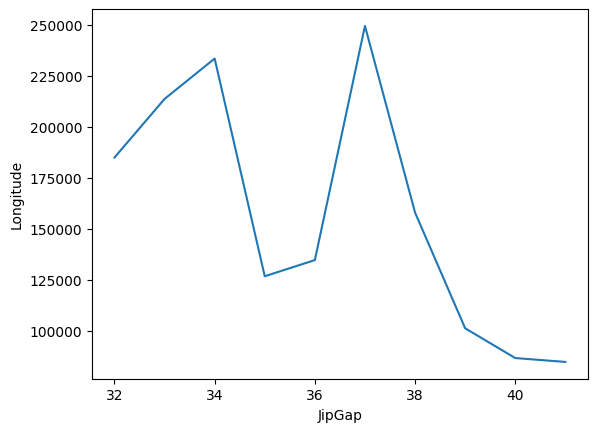

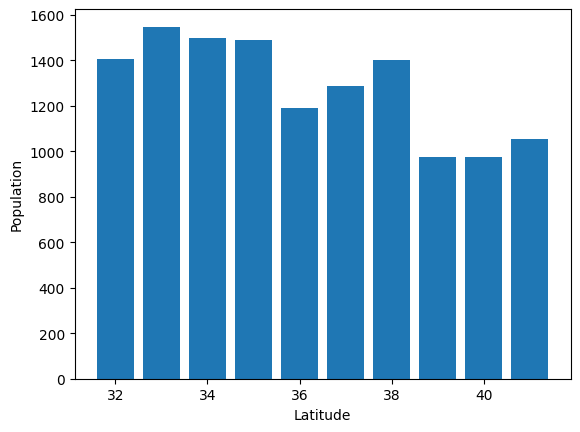

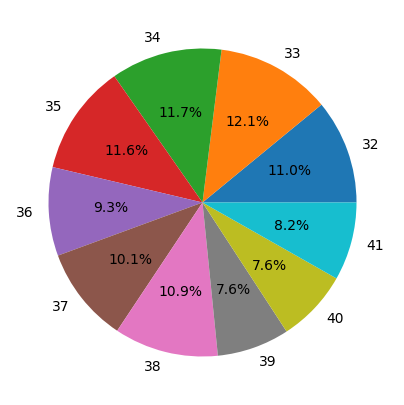

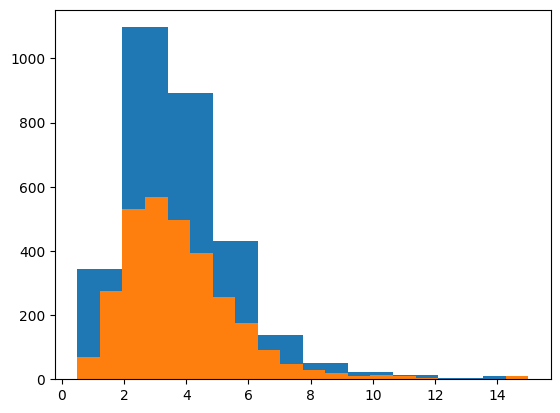

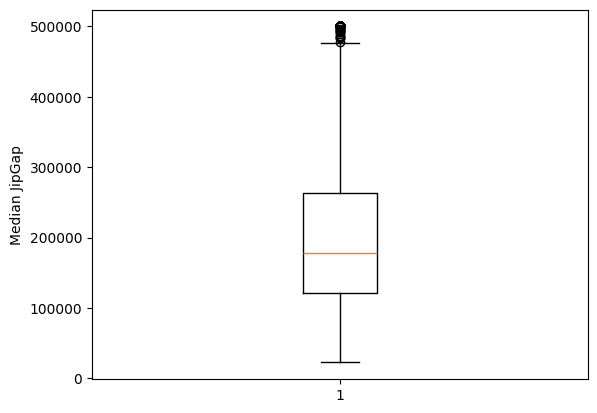

<Axes: title={'center': 'median_house_value'}, xlabel='newLat'>

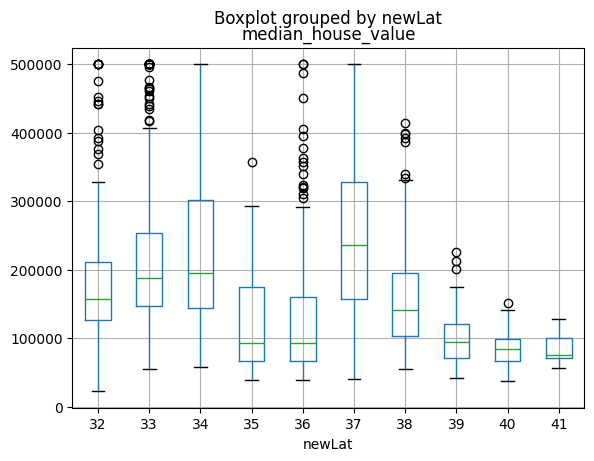

In [ ]:
import matplotlib.pyplot as plt

drx = pd.read_csv('sample_data/california_housing_test.csv', encoding = 'cp949')

drx.insert(0, 'newLat', datRead['latitude'].astype(int))
drx.insert(0, 'newLong', datRead['longitude'].astype(int))

latLong = drx.groupby('newLat').mean()
print(latLong)

# 꺾은선 그래프
plt.figure() # 시각화 시작
plt.plot(latLong['median_house_value']) # 시각화할 데이터 지정

# 축 레이블 표시
plt.xlabel('JipGap')
plt.ylabel('Longitude')
plt.show() # 그래프 표시

lat2 = drx.groupby('newLat').mean()

# 막대 그래프
plt.bar(lat2.index, lat2['population'])
plt.xlabel('Latitude')
plt.ylabel('Population')
plt.show()

# 원 그래프
plt.figure(figsize = (5, 5)) # 그래프 크기 지정
plt.pie(latLong['population'], labels = latLong.index, autopct = '%.1f%%') # labels 반드시 지정 필요
plt.show()

# 히스토그램
plt.figure()
plt.hist(drx['median_income'], bins = 10) # 한 figure 아래에 여러 plot 있으면
plt.hist(drx['median_income'], bins = 20) # 여러 그래프를 한데 모아 표시　가능
plt.show()

# Box plot
plt.boxplot(drx['median_house_value'])
plt.ylabel('Median JipGap')
plt.show()

# Box plot (in DataFrame)
drx.boxplot(column ='median_house_value', by = 'newLat')


## 다변량 시각화

산점도 (scatter plot): plt.scatter()

히트맵: plt.pcolor()

값의 상관관계를 표시할 때 사용

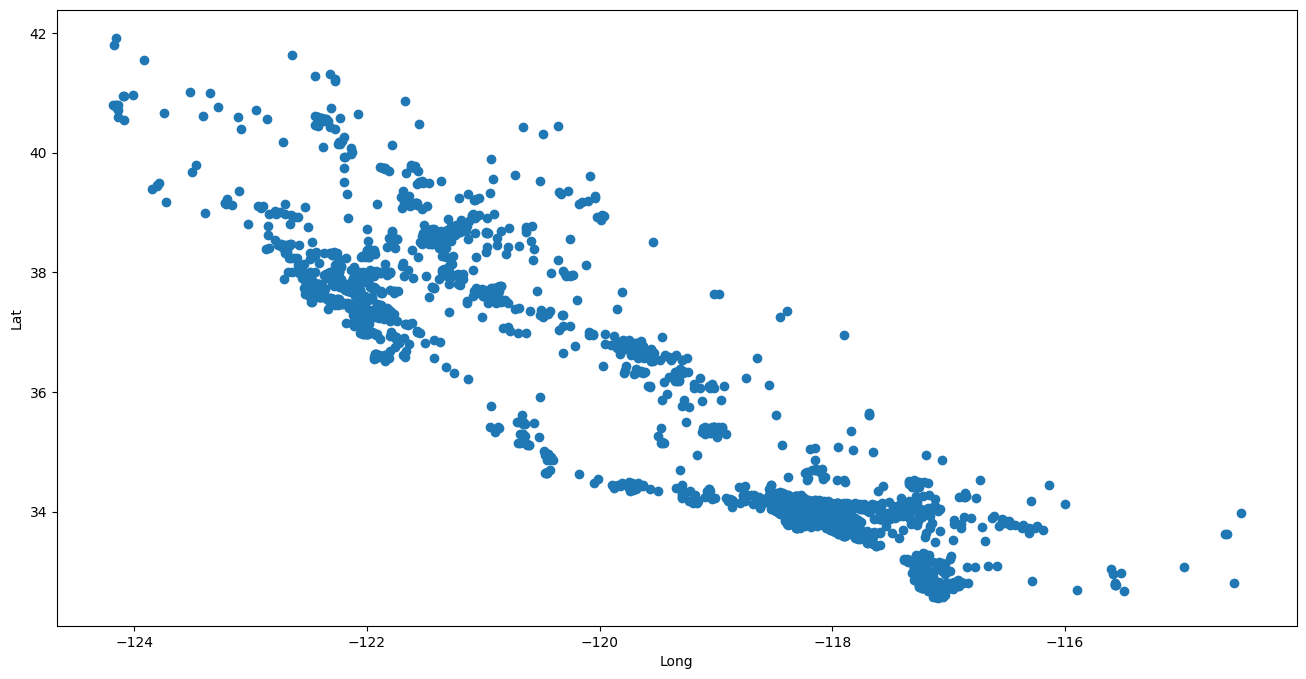

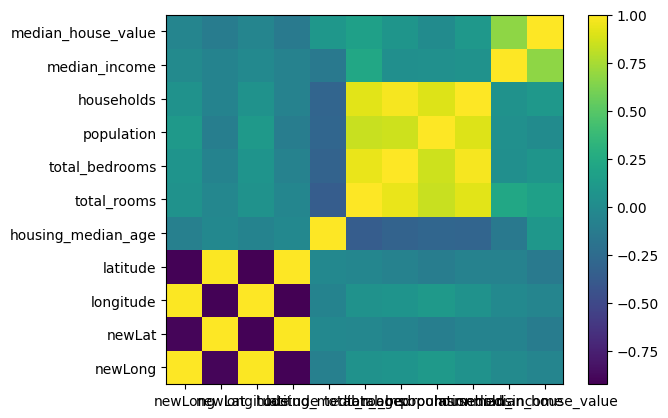

In [ ]:
plt.figure(figsize = (16, 8))
plt.scatter(y = drx['latitude'], x = drx['longitude'])
plt.xlabel('Long')
plt.ylabel('Lat')
plt.show()

dCorr = drx.corr()
plt.pcolor(dCorr)
plt.xticks(np.arange(0.5, len(dCorr.columns), 1), dCorr.columns) # 축의 눈금 위치와 레이블 설정
plt.yticks(np.arange(0.5, len(dCorr.index), 1), dCorr.index) # 축의 눈금 위치와 레이블 설정
plt.colorbar()
plt.show()

## 데이터 정제하기

결측치(값 없는 부분, 보통 NaN) 검출

.info(): 각 열의 정보 출력

-> entries랑 Non-null 수가 다르면 NaN 존재

.isnull(): 각 칸이 NaN인지 여부를 출력

-> .sum(axis = 0) 사용시 열 단위로 true인 칸 개수 출력

(DataFrame이면 항상 사용 가능)

In [ ]:
import random
datNan = pd.read_csv('drive/MyDrive/dat/Clean_Dataset.csv', encoding = 'cp949')
print(datNan.head())
datNan.drop([datNan.columns[0]], axis = 1, inplace = True)

for i in range(5000):
  datNan.iloc[[random.randint(0, 300000)], [random.randint(0, 10)]] = np.nan
datNan.iloc[1] = np.nan
datNan.iloc[3] = np.nan

datNan.info()
datNan.isnull().sum() # 왠진 몰라도 axis = 0이어야 각 열의 합이 나온다.
# 그냥 axis를 넣지 말도록 하자.

   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2           2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3           3   Vistara   UK-995       Delhi        Morning  zero   
4           4   Vistara   UK-963       Delhi        Morning  zero   

    arrival_time destination_city    class  duration  days_left  price  
0          Night           Mumbai  Economy      2.17          1   5953  
1        Morning           Mumbai  Economy      2.33          1   5953  
2  Early_Morning           Mumbai  Economy      2.17          1   5956  
3      Afternoon           Mumbai  Economy      2.25          1   5955  
4        Morning           Mumbai  Economy      2.33          1   5955  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Coun

,0
airline,475
flight,444
source_city,437
departure_time,479
stops,441
arrival_time,454
destination_city,418
class,484
duration,441
days_left,475


결측치는 모델 성능에 영향을 주므로 처리돼야 한다.

1. 결측치 포함 데이터(행) 삭제

    .dropna()

    how: any이면 하나라도 있으면 삭제(기본), all이면 전부 NaN일때만 삭제

    thresh: 멀쩡한 값이 지정한 개수 미만일 때 삭제
    
    axis: 0이면 행, 1이면 열

2. 결측치 비중 높은 열 삭제

    특성 하나를 아예 제거

    열 삭제는 50% 넘을 때만 고려하기

3. 적절히 채워넣기

    남아있는 값들의 평균, 중간, 최빈값(**mode**) 등으로 빈칸 채우기

    (평균, 중간 등 숫자만 되는 놈들은 반드시 **numeric_only** 써서 계산!!!)

    .fillna(값)

    .ffill() / .bfill(): 빈 칸을 이전(ffill)/다음(bfill) 칸의 값으로 채워줌

    너무 많으면 데이터 경향이 바뀔수 있으니 주의

In [ ]:
# 행 삭제
datNanT1 = datNan.copy() # DataFrame 복제
datNanT1.dropna(inplace = True)
datNanT1.info()

datNanT2 = datNan.copy()
datNanT2.dropna(inplace = True, how = 'all')
datNanT2.info()

datNanT3 = datNan.copy()
datNanT3.dropna(inplace = True, thresh = 10)
datNanT3.info()

# 열 삭제
datNanT4 = datNan.copy()
datNanT4.drop(['stops', 'flight'], axis = 1, inplace = True) # 두 개의 열을 삭제
datNanT4.dropna(inplace = True) # 그런 다음 dropna 실행
datNanT4.info() # 아까보다 삭제된 데이터 양이 감소함

# 채워넣기
datNanT5 = datNan.copy()
datNanT5 = datNanT5.fillna(datNanT5.mean(numeric_only = True)) # 평균 구할때 numeric_only 안쓰면 숫자 아닌 값들에서 오류 발생!
datNanT5.info() # 숫자들만 채웠으므로 object 행들은 그대로
print(datNanT5.head())

# datNanT5.fillna(method = 'bfill', inplace = True) # 빈칸을 다음 칸 값으로 채우기
datNanT5.bfill(inplace = True) # 위에 함수는 deprecated, 함수 이름을 b/ffil로 쓰자
datNanT5.info()
print(datNanT5.head())

<class 'pandas.core.frame.DataFrame'>
Index: 295188 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           295188 non-null  object 
 1   flight            295188 non-null  object 
 2   source_city       295188 non-null  object 
 3   departure_time    295188 non-null  object 
 4   stops             295188 non-null  object 
 5   arrival_time      295188 non-null  object 
 6   destination_city  295188 non-null  object 
 7   class             295188 non-null  object 
 8   duration          295188 non-null  float64
 9   days_left         295188 non-null  float64
 10  price             295188 non-null  float64
dtypes: float64(3), object(8)
memory usage: 27.0+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 300151 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline   

이상치(Outlier) 파악하기

Feeling old yet?

scatter plot을 통한 확인, Z-score, IQR 등등

1. Z-score

    신뢰 수준: 신뢰구간에 모집단의 실제 평균이 포함될 확률

    Z = (x_i - X_mean) / (X_std) [95%: 1.96]

    DataFrame의 인덱싱 기능을 통해 조건식 삽입해서 확인

2. IQR(Inter Quartile Range)

    IQR = 3사분위수[Q3, 상위 25% 값] - 1사분위수[Q1, 하위 25% 값]

    outlier: N < Q1 - 1.5 * IQR || N > Q3 + 1.5 * IQR인 경우

    [].quantile(n): 하위 n(0<=n<=1)에 해당하는 값 반환

        Unnamed: 0  airline  flight source_city departure_time stops  \
206691      206691  Vistara  UK-809       Delhi        Evening   one   
206692      206692  Vistara  UK-813       Delhi        Evening   one   
206693      206693  Vistara  UK-809       Delhi        Evening   one   
206694      206694  Vistara  UK-809       Delhi        Evening   one   
206695      206695  Vistara  UK-813       Delhi        Evening   one   
...            ...      ...     ...         ...            ...   ...   
300148      300148  Vistara  UK-822     Chennai        Morning   one   
300149      300149  Vistara  UK-826     Chennai      Afternoon   one   
300150      300150  Vistara  UK-832     Chennai  Early_Morning   one   
300151      300151  Vistara  UK-828     Chennai  Early_Morning   one   
300152      300152  Vistara  UK-822     Chennai        Morning   one   

       arrival_time destination_city     class  duration  days_left  price  
206691      Morning           Mumbai  Business     12.42  

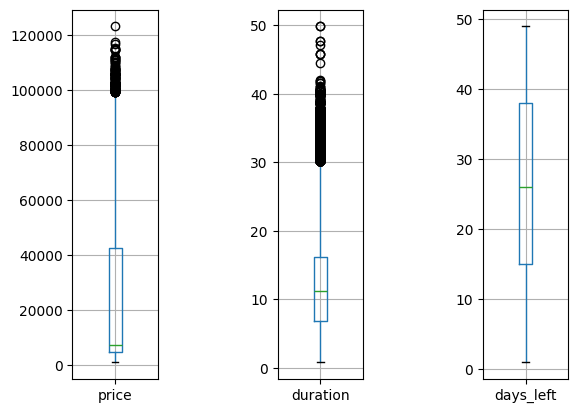

In [ ]:
# Z-score 방법
dat = pd.read_csv('drive/MyDrive/dat/Clean_Dataset.csv', encoding = 'cp949')
print(dat[abs(dat['price'] - dat['price'].mean()) / dat['price'].std() > 1.96]) # 신뢰수준 95% 밖에 있는 데이터(outlier)만 필터링

# IQR 방법
q1 = dat['price'].quantile(0.25)
q3 = dat['price'].quantile(0.75)
iqr = q3 - q1
lowerTh = q1 - iqr * 1.5
upperTh = q3 + iqr * 1.5
dat[(dat['price'] < lowerTh) | (dat['price']> upperTh)] # IQR 기준의 바깥에 있는 값들(outlier)만 표시

plt.figure()
plt.subplot(151)
dat[['price']].boxplot() # 이런 경우는 반드시 list 형태로 줘야
plt.subplot(153)
dat[['duration']].boxplot()
plt.subplot(155)
dat[['days_left']].boxplot()
plt.show()

이상치 처리하기

1. 삭제(Z-score)

    위에 방법대로 찾은 다음 그냥 drop 사용
    
    데이터 손실 주의

2. 대체(IQR)

    IQR 기준값보다 위에 있으면 최댓값으로, 아래에 있으면 최솟값으로 대체

    **loc을 사용하면 조건에 해당하는 모든 셀을 한 번에 접근할 수 있다**

    **loc[행 조건, 열 조건] <-- 반드시 열을 지정해줘야 한다**

<class 'pandas.core.frame.DataFrame'>
Index: 287660 entries, 0 to 300146
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        287660 non-null  int64  
 1   airline           287660 non-null  object 
 2   flight            287660 non-null  object 
 3   source_city       287660 non-null  object 
 4   departure_time    287660 non-null  object 
 5   stops             287660 non-null  object 
 6   arrival_time      287660 non-null  object 
 7   destination_city  287660 non-null  object 
 8   class             287660 non-null  object 
 9   duration          287660 non-null  float64
 10  days_left         287660 non-null  int64  
 11  price             287660 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 28.5+ MB
None


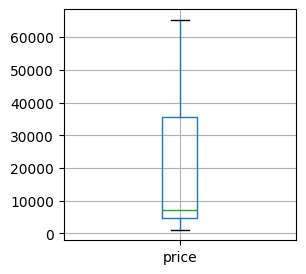

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB
None


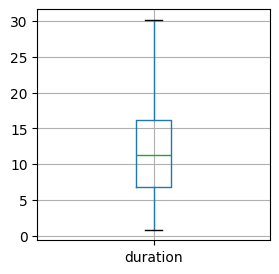

In [44]:
# 삭제
datOut = dat.copy()
outlier = datOut[abs(datOut['price'] - datOut['price'].mean()) / datOut['price'].std() > 1.96].index
datOut.drop(outlier, inplace = True)
print(datOut.info())

plt.figure(figsize = (3, 3))
datOut.boxplot('price')
plt.show()

# 대체
datRep = dat.copy()
q3 = datRep['duration'].quantile(0.75)
q1 = datRep['duration'].quantile(0.25)
iqr = q3 - q1
datRep.loc[datRep['duration'] > q3 + iqr * 1.5, 'duration'] = q3 + iqr * 1.5 # 위쪽 outlier
datRep.loc[datRep['duration'] < q1 - iqr * 1.5, 'duration'] = q1 - iqr * 1.5 # 아래쪽 outlier
print(datRep.info())

plt.figure(figsize = (3, 3))
datRep.boxplot('duration')
plt.show()


## 구간화

연속형(수치) 데이터를 특정 구간으로 나누어 범주형 데이터로 변환

(위도를 반올림해서 정수 범주형으로 바꾼 것과 동일)

pd.cut: 동일 길이로 분할

    bins: 분할 기준점이 되는 값들의 list
    labels: 분할된 각 구간들의 이름 list
    (labels는 bins보다 하나 적어야 함)

pd.qcut: 동일 개수로 분할

    bins 대신 분할할 구간의 개수 지정
    labels는 그대로, 구간 개수만큼 list로 지정

구간화 데이터들의 각 구간 개수는 .value_counts()로 출력가능

In [53]:
datBin = datRep.copy()
datBin.sort_values('days_left', ascending = False, inplace = True)

datBin['affordability'] = pd.cut(datBin['price'], bins = [0, 20000, 40000, 60000, 80000, 100000], labels = ['steal', 'cheap', 'mid', 'expensive', 'fraud'])
datBin['length'] = pd.qcut(datBin['duration'], 4, labels = ['very short', 'short', 'medium', 'long'])

print(datBin.head(10))
print(datBin['affordability'].value_counts())
print(datBin['length'].value_counts())

        Unnamed: 0   airline  flight source_city departure_time stops  \
300132      300132   Vistara  UK-834     Chennai        Evening   one   
300133      300133   Vistara  UK-834     Chennai        Evening   one   
300152      300152   Vistara  UK-822     Chennai        Morning   one   
300151      300151   Vistara  UK-828     Chennai  Early_Morning   one   
300150      300150   Vistara  UK-832     Chennai  Early_Morning   one   
300149      300149   Vistara  UK-826     Chennai      Afternoon   one   
165557      165557   Vistara  UK-860   Hyderabad  Early_Morning   one   
165558      165558   Vistara  UK-659   Hyderabad        Morning   one   
165559      165559   Vistara  UK-659   Hyderabad        Morning   one   
165560      165560  GO_FIRST  G8-513   Hyderabad        Morning   one   

       arrival_time destination_city     class  duration  days_left  price  \
300132      Morning        Hyderabad  Business     16.00         49  51457   
300133    Afternoon        Hyderabad  Bu